In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor

In [2]:
DATA_PATH = Path("../data/assurance-maladie.csv")

df = pd.read_csv(DATA_PATH)

df = df.drop_duplicates()

In [3]:
X = df.drop("charges", axis=1)
y = df["charges"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [4]:
numeric_features = ["age", "bmi", "children"]
categorical_features = ["sex", "smoker", "region"]

numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [5]:
best_xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            XGBRegressor(
                random_state=42,
                learning_rate=0.05,
                max_depth=3,
                n_estimators=300,
                subsample=1.0
            )
        )
    ]
)

In [6]:
best_xgb_pipeline.fit(X_train, y_train)

predictions = best_xgb_pipeline.predict(X_test)

In [7]:
residuals = y_test - predictions

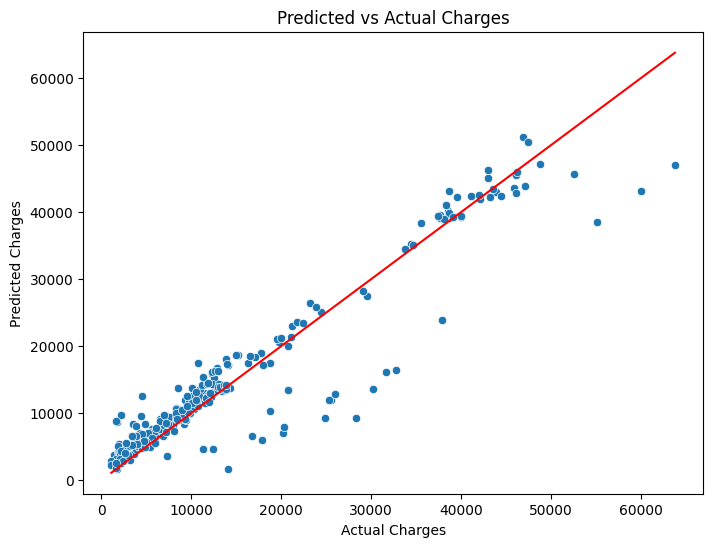

In [8]:
plt.figure(figsize=(8, 6))

sns.scatterplot(x=y_test, y=predictions)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Predicted vs Actual Charges")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.show()

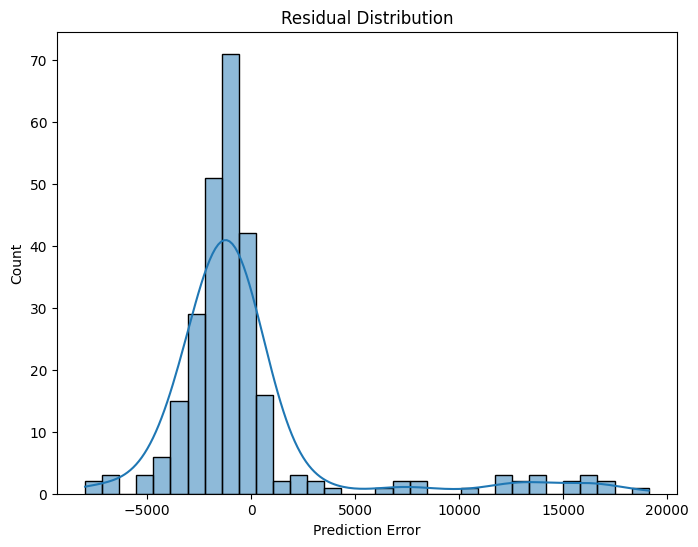

In [9]:
plt.figure(figsize=(8, 6))

sns.histplot(residuals, kde=True)

plt.title("Residual Distribution")
plt.xlabel("Prediction Error")

plt.show()

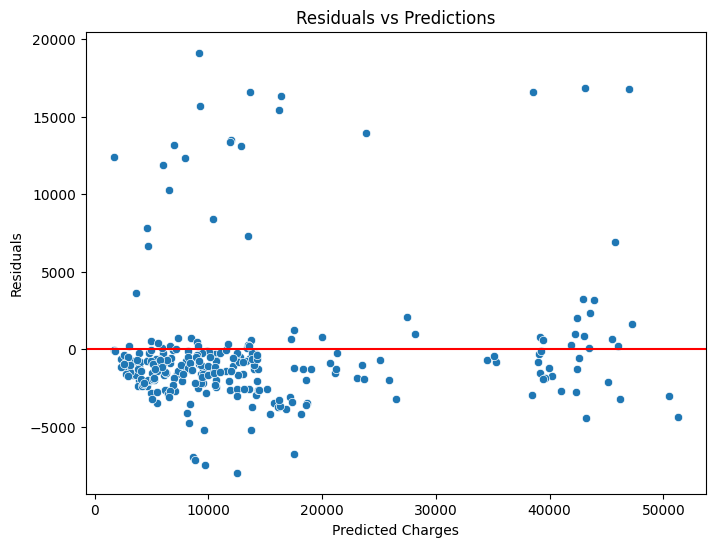

In [10]:
plt.figure(figsize=(8, 6))

sns.scatterplot(x=predictions, y=residuals)

plt.axhline(y=0, color="red")

plt.xlabel("Predicted Charges")
plt.ylabel("Residuals")

plt.title("Residuals vs Predictions")

plt.show()

In [11]:
rmse = mean_squared_error(y_test, predictions) ** 0.5
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"RMSE: {rmse:.2f}")
print(f"MAE : {mae:.2f}")
print(f"R2  : {r2:.4f}")

RMSE: 4360.22
MAE : 2578.93
R2  : 0.8965
